In [42]:
from pathlib import Path
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.options.display.float_format = "{:,.4f}".format

from Scripts.weekly_view import build_weekly_view
from Scripts.schedule import build_season_schedule

# --- config ---
PROJECT_ROOT = Path("/Users/joshmacbook/python_projects/OAD")
YEARS = [2024, 2025]

# choose which weekly table to evaluate (summary is best; it contains everything)
SUMMARY_KEY = "summary"

# top 10% definition: by finish_num within actual field
TOP_PCT = 0.10

In [43]:
from Scripts.data_io import load_odds_and_results

odds_df = load_odds_and_results()

def build_event_top10pct_labels(odds_df: pd.DataFrame, year: int, event_id: int, top_pct: float = 0.10) -> pd.DataFrame:
    """
    Returns dg_id + is_top10pct for that event, based on finish_num ranks among players with numeric finish.
    """
    o = odds_df.copy()
    for c in ["year", "event_id", "dg_id", "finish_num"]:
        if c in o.columns:
            o[c] = pd.to_numeric(o[c], errors="coerce")

    ev = o[(o["year"] == int(year)) & (o["event_id"] == int(event_id))].copy()
    if ev.empty:
        return pd.DataFrame(columns=["dg_id", "finish_num", "field_n", "top_n", "is_top10pct"])

    # only players with a numeric finish count as the ranked field
    ev = ev[ev["finish_num"].notna()].copy()
    if ev.empty:
        return pd.DataFrame(columns=["dg_id", "finish_num", "field_n", "top_n", "is_top10pct"])

    field_n = len(ev)
    top_n = max(1, int(np.ceil(field_n * float(top_pct))))

    ev["field_n"] = field_n
    ev["top_n"] = top_n
    ev["is_top10pct"] = ev["finish_num"].rank(method="min") <= top_n

    return ev[["dg_id", "finish_num", "field_n", "top_n", "is_top10pct"]].copy()

In [44]:
def harvest_weekly_summaries_for_year(year: int) -> pd.DataFrame:
    sched = build_season_schedule(int(year))
    rows = []

    for _, r in sched.iterrows():
        eid = int(r["event_id"])

        # build weekly view (unfiltered: we want the full field)
        weekly_raw = build_weekly_view(int(year), eid)

        if SUMMARY_KEY not in weekly_raw:
            continue

        summ = weekly_raw[SUMMARY_KEY].copy()
        if summ.empty or "dg_id" not in summ.columns:
            continue

        summ["year"] = int(year)
        summ["event_id"] = eid
        summ["event_name"] = str(r.get("event_name", ""))

        # attach tier if present in schedule
        if "event_tier" in sched.columns:
            summ["event_tier"] = str(r.get("event_tier", "")).lower()
        elif "Event_Tier" in sched.columns:
            summ["event_tier"] = str(r.get("Event_Tier", "")).lower()
        else:
            summ["event_tier"] = ""

        # attach event_date if present
        if "event_date" in sched.columns:
            summ["event_date"] = pd.to_datetime(r.get("event_date"), errors="coerce")

        rows.append(summ)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    # normalize types
    out["dg_id"] = pd.to_numeric(out["dg_id"], errors="coerce")
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out["event_id"] = pd.to_numeric(out["event_id"], errors="coerce")
    return out

In [45]:
all_years = []
for y in YEARS:
    print("Harvesting year:", y)
    df_y = harvest_weekly_summaries_for_year(y)
    print("  rows:", len(df_y), "cols:", len(df_y.columns))
    all_years.append(df_y)

df = pd.concat(all_years, ignore_index=True)
print("TOTAL rows:", len(df), "TOTAL cols:", len(df.columns))

# attach top10% label per (year, event_id, dg_id)
labels = []
for (y, eid), _ in df.groupby(["year", "event_id"]):
    lab = build_event_top10pct_labels(odds_df, int(y), int(eid), top_pct=TOP_PCT)
    if not lab.empty:
        lab["year"] = int(y)
        lab["event_id"] = int(eid)
        labels.append(lab)

labels_df = pd.concat(labels, ignore_index=True) if labels else pd.DataFrame(columns=["year","event_id","dg_id","is_top10pct"])

df = df.merge(labels_df[["year","event_id","dg_id","is_top10pct","finish_num","field_n","top_n"]],
              on=["year","event_id","dg_id"], how="left")

df["is_top10pct"] = df["is_top10pct"].fillna(False).astype(bool)

print("Top10% rate:", df["is_top10pct"].mean())
df.head()

Harvesting year: 2024
  rows: 3840 cols: 81
Harvesting year: 2025
  rows: 3853 cols: 81
TOTAL rows: 7693 TOTAL cols: 81
Top10% rate: 0.07006369426751592


,year,event_id,dg_id,player_name_x,Event_Tier,close_odds,sg_total_L40,sg_app_L40,sg_arg_L40,sg_putt_L40,driving_dist_L40,driving_acc_L40,round_score_L40,sg_total_L24,sg_app_L24,sg_arg_L24,sg_putt_L24,driving_dist_L24,driving_acc_L24,round_score_L24,sg_total_L12,sg_app_L12,sg_arg_L12,sg_putt_L12,driving_dist_L12,driving_acc_L12,round_score_L12,starts_event,made_cuts_event,made_cut_pct_event,top25_event,top10_event,top5_event,wins_event,prev_finish_num_event,prev_finish_text_event,avg_score_event,avg_sg_total_event,player_name_y,ytd_made_cuts,ytd_top25,ytd_top10,ytd_top5,ytd_wins,ytd_starts,ytd_made_cut_pct,ytd_avg_score,ytd_avg_sg_total,course_fit_score,decimal_odds,ev_current,ev_future_total,ev_future_max,ev_current_pct_of_future,ev_current_vs_future_max_pct,is_liv,tag_event_1,tag_event_2,tag_event_3,tag_event_4,is_shortlist,tagged_here,ev_current_adj,ev_future_total_adj,ev_future_max_adj,ev_current_to_future_max_ratio,z_sg_recent,z_ytd,event_hist_raw,event_hist_z,history_metric,z_history,z_ev_current,oad_score,pattern_score_winner,pattern_flag_winner,pattern_score_top5,pattern_flag_top5,event_name,event_tier,event_date,is_top10pct,finish_num,field_n,top_n
0,2024,6,13562,"Matsuyama, Hideki",REGULAR,41.0000,0.3548,0.7249,0.0802,-0.3968,292.4778,0.6099,69.8500,-0.2745,0.4409,-0.0099,-0.6293,294.8850,0.5812,69.7500,-1.0773,-0.0410,0.2532,-1.0505,303.5750,0.5601,70.4167,6.0000,6.0000,1.0000,3.0000,1.0000,1.0000,1.0000,48.0000,48,67.1667,1.4250,"Matsuyama, Hideki",1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,71.0000,-2.6353,0.2629,10.0000,"830,000.0000","12,565,221.8782","500,000.0000",0.0661,1.6600,NaN,<NA>,<NA>,<NA>,<NA>,False,False,"863,891.3898","13,078,297.5798","520,416.4999",1.6600,0.8503,0.0000,0.7658,0.9223,0.9223,0.9223,1.0000,0.6746,4,False,5,False,Sony Open in Hawaii,regular,2024-01-14,False,30.0000,81.0000,9.0000
1,2024,6,17576,"Conners, Corey",REGULAR,29.0000,0.6066,0.4532,-0.0995,-0.3632,296.7361,0.6231,68.8500,0.1640,0.3658,-0.1743,-0.5557,301.0050,0.5978,68.6667,-0.1673,0.6530,-0.3863,-1.0773,306.7500,0.6196,68.5833,5.0000,5.0000,1.0000,4.0000,1.0000,1.0000,0.0000,12.0000,12,67.0500,1.7987,"Conners, Corey",1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,68.5000,-0.1352,0.9710,15.0000,"553,333.3333","6,871,927.1166","378,787.8788",0.0805,1.4608,NaN,<NA>,<NA>,<NA>,<NA>,False,False,"575,927.5932","7,152,528.5147","394,254.9241",1.4608,0.8857,0.0000,0.6751,0.8129,0.8129,0.8129,0.6660,0.6168,4,False,5,False,Sony Open in Hawaii,regular,2024-01-14,False,57.0000,81.0000,9.0000
2,2024,6,14796,"Hatton, Tyrrell",REGULAR,17.0000,1.1727,0.2487,0.3298,0.4314,299.3033,0.5519,68.8000,1.0871,-0.1055,0.5768,0.3411,303.8500,0.5346,68.5000,1.6055,0.2433,0.8313,0.3779,305.1143,0.5283,67.6667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Hatton, Tyrrell",1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,67.5000,0.8647,1.4197,17.0000,"488,235.2941","19,093,212.6697","961,538.4615",0.0256,0.5078,False,<NA>,<NA>,<NA>,<NA>,True,False,"508,171.4058","19,872,845.8175","1,000,800.9613",0.5078,0.9573,0.0000,NaN,NaN,0.0000,0.0000,0.5874,0.4710,5,False,5,False,Sony Open in Hawaii,regular,2024-01-14,False,13.0000,81.0000,9.0000
3,2024,6,8825,"Harman, Brian",REGULAR,19.0000,1.4216,0.1244,0.3517,0.9881,291.7781,0.6233,67.9500,0.8009,-0.0104,0.4713,0.6887,297.0938,0.5512,68.0833,1.2485,-0.0104,0.7035,0.8157,301.2286,0.5763,67.6667,7.0000,6.0000,0.8571,2.0000,1.0000,1.0000,0.0000,32.0000,32,68.3571,0.3303,"Harman, Brian",1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,66.7500,1.6147,-0.1115,17.0000,"488,235.2941","6,481,961.0398","543,478.2609",0.0753,0.8984,NaN,<NA>,<NA>,<NA>,<NA>,False,False,"508,171.4058","6,746,638.9532","565,670.1086",0.8984,0.9463,0.4000,0.6701,0.8069,0.8069,0.8069,0.5874,0.7080,7,True,7,True,Sony Open in Hawaii,regular,2024-01-14,False,18.0000,81.0000,9.0000
4,2024,6,17646,"Fitzpatrick, Matt",REGULAR,19.0000,1.1730,-0.2170,0.2890,0.8228,293.1619,0.5130,68.4750,1.4256,-0.2179,0.3696,0.8788,309.1167,0.4978,68.2917,0.7296,-0.2

In [46]:
# Columns inventory (sorted)
cols = sorted(df.columns.tolist())
print("n_cols:", len(cols))
for c in cols:
    print(c)

# quick sanity: show the "big buckets"
print("\nCommon important columns present?")
for c in ["oad_score", "z_sg_recent", "z_ytd", "z_history", "z_ev_current",
          "course_fit_score", "starts_event", "made_cut_pct_event",
          "ytd_starts", "ytd_made_cut_pct", "ytd_top10",
          "sg_total_L12", "sg_total_L24", "sg_total_L40"]:
    print(f"{c:25s}", c in df.columns)

n_cols: 85
Event_Tier
avg_score_event
avg_sg_total_event
close_odds
course_fit_score
decimal_odds
dg_id
driving_acc_L12
driving_acc_L24
driving_acc_L40
driving_dist_L12
driving_dist_L24
driving_dist_L40
ev_current
ev_current_adj
ev_current_pct_of_future
ev_current_to_future_max_ratio
ev_current_vs_future_max_pct
ev_future_max
ev_future_max_adj
ev_future_total
ev_future_total_adj
event_date
event_hist_raw
event_hist_z
event_id
event_name
event_tier
field_n
finish_num
history_metric
is_liv
is_shortlist
is_top10pct
made_cut_pct_event
made_cuts_event
oad_score
pattern_flag_top5
pattern_flag_winner
pattern_score_top5
pattern_score_winner
player_name_x
player_name_y
prev_finish_num_event
prev_finish_text_event
round_score_L12
round_score_L24
round_score_L40
sg_app_L12
sg_app_L24
sg_app_L40
sg_arg_L12
sg_arg_L24
sg_arg_L40
sg_putt_L12
sg_putt_L24
sg_putt_L40
sg_total_L12
sg_total_L24
sg_total_L40
starts_event
tag_event_1
tag_event_2
tag_event_3
tag_event_4
tagged_here
top10_event
top25_event


In [47]:
import numpy as np
import pandas as pd

# normalize tier (you have both Event_Tier and event_tier)
def normalize_tier(x):
    s = str(x).strip().lower()
    if s in ["nan", "none", ""]:
        return ""
    return s

if "Event_Tier" in df.columns:
    df["tier"] = df["Event_Tier"].apply(normalize_tier)
elif "event_tier" in df.columns:
    df["tier"] = df["event_tier"].apply(normalize_tier)
else:
    df["tier"] = ""

# keep only the 3 we care about
df["tier"] = df["tier"].replace({
    "majors": "major",
    "signature event": "signature",
    "sig": "signature",
})

# prefer one player_name column
if "player_name_x" in df.columns and "player_name_y" in df.columns:
    df["player_name"] = df["player_name_x"].fillna(df["player_name_y"])
elif "player_name_x" in df.columns:
    df["player_name"] = df["player_name_x"]
elif "player_name_y" in df.columns:
    df["player_name"] = df["player_name_y"]

# numeric coercions we’ll use
for c in ["oad_score","z_sg_recent","z_ev_current","z_ytd","z_history","course_fit_score",
          "made_cut_pct_event","ytd_made_cut_pct","ytd_starts","ytd_top10",
          "starts_event","ev_current_adj","ev_future_max","decimal_odds"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("rows:", len(df), "cols:", len(df.columns))
print("top10% rate:", df["is_top10pct"].mean())
df[["year","event_id","event_name","tier","dg_id","player_name","is_top10pct","oad_score"]].head()

rows: 7693 cols: 87
top10% rate: 0.07006369426751592


,year,event_id,event_name,tier,dg_id,player_name,is_top10pct,oad_score
0,2024,6,Sony Open in Hawaii,regular,13562,"Matsuyama, Hideki",False,0.6746
1,2024,6,Sony Open in Hawaii,regular,17576,"Conners, Corey",False,0.6168
2,2024,6,Sony Open in Hawaii,regular,14796,"Hatton, Tyrrell",False,0.4710
3,2024,6,Sony Open in Hawaii,regular,8825,"Harman, Brian",False,0.7080
4,2024,6,Sony Open in Hawaii,regular,17646,"Fitzpatrick, Matt",False,0.4562


In [48]:
def add_event_decile(df_in: pd.DataFrame, score_col: str, out_col: str) -> pd.DataFrame:
    df2 = df_in.copy()

    def _make_decile(s: pd.Series) -> pd.Series:
        s = pd.to_numeric(s, errors="coerce")
        if s.notna().sum() < 10:
            return pd.Series([np.nan] * len(s), index=s.index)
        r = s.rank(method="first")
        return pd.qcut(r, 10, labels=False, duplicates="drop")

    df2[out_col] = df2.groupby(["year","event_id"])[score_col].transform(_make_decile)
    df2 = df2[df2[out_col].notna()].copy()
    df2[out_col] = df2[out_col].astype(int)
    return df2

In [49]:
BASELINE = df["is_top10pct"].mean()

def decile_lift(df_in: pd.DataFrame, score_col: str, decile_col: str = "decile") -> pd.DataFrame:
    tmp = add_event_decile(df_in, score_col=score_col, out_col=decile_col)

    rows = []
    for (y, eid), g in tmp.groupby(["year","event_id"]):
        for d, gd in g.groupby(decile_col):
            rows.append({
                "year": int(y),
                "event_id": int(eid),
                "decile": int(d),
                "top10pct_rate": float(gd["is_top10pct"].mean()),
                "n": int(len(gd)),
            })

    out = (pd.DataFrame(rows)
           .groupby("decile", as_index=False)
           .agg(avg_top10pct_rate=("top10pct_rate","mean"),
                avg_n=("n","mean"))
           .sort_values("decile", ascending=True))

    out["lift_vs_baseline"] = out["avg_top10pct_rate"] / BASELINE
    return out

def decile_lift_by_tier(df_in: pd.DataFrame, score_col: str) -> dict:
    out = {"overall": decile_lift(df_in, score_col)}
    for t in ["major","signature","regular"]:
        sub = df_in[df_in["tier"] == t].copy()
        if len(sub) > 0:
            out[t] = decile_lift(sub, score_col)
    return out

In [50]:
CANDIDATES = [
    "oad_score",
    "z_sg_recent",
    "z_ytd",
    "z_history",
    "z_ev_current",
    "course_fit_score",
    "made_cut_pct_event",
    "starts_event",
    "ytd_made_cut_pct",
    "ytd_starts",
    "ytd_top10",
    "ev_current_adj",
    "ev_future_max",
    "decimal_odds",
    "sg_total_L12",
    "sg_total_L24",
    "sg_total_L40",
]

CANDIDATES = [c for c in CANDIDATES if c in df.columns]
print("CANDIDATES:", CANDIDATES)

feature_summary = []
for c in CANDIDATES:
    dl = decile_lift(df, c)
    # use top decile (decile==9) rate as simple “how good is it at the top”
    top = dl.loc[dl["decile"] == dl["decile"].max(), "avg_top10pct_rate"].iloc[0]
    feature_summary.append({
        "feature": c,
        "top_decile_top10pct_rate": top,
        "top_decile_lift": top / BASELINE
    })

feature_rank = pd.DataFrame(feature_summary).sort_values("top_decile_lift", ascending=False)
display(feature_rank)

CANDIDATES: ['oad_score', 'z_sg_recent', 'z_ytd', 'z_history', 'z_ev_current', 'course_fit_score', 'made_cut_pct_event', 'starts_event', 'ytd_made_cut_pct', 'ytd_starts', 'ytd_top10', 'ev_current_adj', 'ev_future_max', 'decimal_odds', 'sg_total_L12', 'sg_total_L24', 'sg_total_L40']


,feature,top_decile_top10pct_rate,top_decile_lift
14,sg_total_L12,0.3065,4.3746
1,z_sg_recent,0.2949,4.2094
15,sg_total_L24,0.2768,3.9514
16,sg_total_L40,0.2704,3.8590
0,oad_score,0.2418,3.4511
4,z_ev_current,0.2259,3.2236
11,ev_current_adj,0.2259,3.2236
12,ev_future_max,0.2168,3.0940
2,z_ytd,0.1962,2.7998
10,ytd_top10,0.1673,2.3873


In [51]:
tier_rank_rows = []

for t in ["major","signature","regular"]:
    sub = df[df["tier"] == t].copy()
    if sub.empty:
        continue
    base_t = sub["is_top10pct"].mean()

    for c in CANDIDATES:
        dl = decile_lift(sub, c)
        top = dl.loc[dl["decile"] == dl["decile"].max(), "avg_top10pct_rate"].iloc[0]
        tier_rank_rows.append({
            "tier": t,
            "feature": c,
            "baseline": base_t,
            "top_decile_rate": top,
            "top_decile_lift": (top / base_t) if base_t > 0 else np.nan,
        })

tier_rank = pd.DataFrame(tier_rank_rows).sort_values(["tier","top_decile_lift"], ascending=[True, False])
display(tier_rank)

,tier,feature,baseline,top_decile_rate,top_decile_lift
14,major,sg_total_L12,0.0671,0.3260,4.8558
1,major,z_sg_recent,0.0671,0.3057,4.5533
0,major,oad_score,0.0671,0.2839,4.2280
4,major,z_ev_current,0.0671,0.2745,4.0879
11,major,ev_current_adj,0.0671,0.2745,4.0879
12,major,ev_future_max,0.0671,0.2667,3.9716
15,major,sg_total_L24,0.0671,0.2667,3.9716
16,major,sg_total_L40,0.0671,0.2510,3.7388
5,major,course_fit_score,0.0671,0.2087,3.1081
3,major,z_history,0.0671,0.1998,2.9761


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# choose features for the model (start conservative)
LR_FEATURES = [
    "z_sg_recent",
    "z_ytd",
    "z_history",
    "z_ev_current",
    "course_fit_score",
    "made_cut_pct_event",
    "ytd_made_cut_pct",
]

LR_FEATURES = [c for c in LR_FEATURES if c in df.columns]
print("LR_FEATURES:", LR_FEATURES)

# event-wise zscore for robustness
def event_zscore(df_in: pd.DataFrame, col: str) -> pd.Series:
    def _z(s):
        s = pd.to_numeric(s, errors="coerce")
        mu = s.mean()
        sd = s.std(ddof=0)
        if sd == 0 or np.isnan(sd):
            return pd.Series([0.0]*len(s), index=s.index)
        return (s - mu) / sd
    return df_in.groupby(["year","event_id"])[col].transform(_z)

X = pd.DataFrame({c: event_zscore(df, c) for c in LR_FEATURES})
y = df["is_top10pct"].astype(int)

# fill NAs
X = X.fillna(0.0)

# fit regularized model
lr = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=2000
)
lr.fit(X, y)

# score = linear predictor (higher = better)
df["oad_score_lr"] = lr.decision_function(X)

# inspect weights
w = pd.DataFrame({"feature": LR_FEATURES, "coef": lr.coef_[0]})
w["abs"] = w["coef"].abs()
w = w.sort_values("abs", ascending=False).drop(columns="abs")
display(w)

# quick global AUC just as sanity (not the objective, but useful)
auc = roc_auc_score(y, df["oad_score_lr"])
print("AUC (overall):", auc)

# compare decile lift: original vs lr-score
print("=== decile lift: oad_score ===")
display(decile_lift(df, "oad_score"))

print("=== decile lift: oad_score_lr ===")
display(decile_lift(df, "oad_score_lr"))

LR_FEATURES: ['z_sg_recent', 'z_ytd', 'z_history', 'z_ev_current', 'course_fit_score', 'made_cut_pct_event', 'ytd_made_cut_pct']


,feature,coef
0,z_sg_recent,1.4907
1,z_ytd,-0.3496
6,ytd_made_cut_pct,0.3081
3,z_ev_current,0.1651
2,z_history,0.1611
5,made_cut_pct_event,-0.0744
4,course_fit_score,0.0379


AUC (overall): 0.8125819824969153
=== decile lift: oad_score ===


,decile,avg_top10pct_rate,avg_n,lift_vs_baseline
0,0,0.0025,11.3226,0.0354
1,1,0.0227,10.8871,0.3239
2,2,0.0275,10.8065,0.3929
3,3,0.0468,10.8226,0.6678
4,4,0.0737,10.9194,1.0515
5,5,0.0573,10.6774,0.8184
6,6,0.0925,10.7419,1.3196
7,7,0.1178,10.8871,1.6808
8,8,0.1534,10.8065,2.1888
9,9,0.2418,11.1774,3.4511


=== decile lift: oad_score_lr ===


,decile,avg_top10pct_rate,avg_n,lift_vs_baseline
0,0,0.0000,12.8871,0.0000
1,1,0.0174,12.2903,0.2490
2,2,0.0117,12.2903,0.1672
3,3,0.0227,12.3710,0.3241
4,4,0.0464,12.4032,0.6628
5,5,0.0595,12.2097,0.8497
6,6,0.0582,12.2097,0.8306
7,7,0.1014,12.4516,1.4475
8,8,0.1313,12.1290,1.8741
9,9,0.3092,12.8387,4.4124


In [53]:
def top_decile_rate_by_event(df_in: pd.DataFrame, score_col: str) -> pd.DataFrame:
    tmp = add_event_decile(df_in, score_col=score_col, out_col="decile_tmp")
    # top decile = highest label in this event (in case qcut dropped bins)
    ev_top = (
        tmp.groupby(["year","event_id"])
        .apply(lambda g: g[g["decile_tmp"] == g["decile_tmp"].max()]["is_top10pct"].mean())
        .reset_index(name="top_decile_rate")
    )
    return ev_top

ev_v1 = top_decile_rate_by_event(df, "oad_score").rename(columns={"top_decile_rate":"v1"})
ev_lr = top_decile_rate_by_event(df, "oad_score_lr").rename(columns={"top_decile_rate":"lr"})

ev_cmp = ev_v1.merge(ev_lr, on=["year","event_id"], how="inner")
ev_cmp["winner"] = np.where(ev_cmp["lr"] > ev_cmp["v1"], "lr",
                    np.where(ev_cmp["lr"] < ev_cmp["v1"], "v1", "tie"))

print(ev_cmp["winner"].value_counts())
display(ev_cmp.sort_values(["year","event_id"]))

winner
lr     41
v1     14
tie     7
Name: count, dtype: int64


,year,event_id,v1,lr,winner
0,2024,2,0.2500,0.2500,tie
1,2024,3,0.3077,0.3077,tie
2,2024,4,0.1333,0.2500,lr
3,2024,5,0.1250,0.3750,lr
4,2024,6,0.2500,0.0667,v1
...,...,...,...,...,...
57,2025,480,0.5714,0.6250,lr
58,2025,524,0.2000,0.3750,lr
59,2025,525,0.1333,0.2500,lr
60,2025,540,0.1818,0.3077,lr


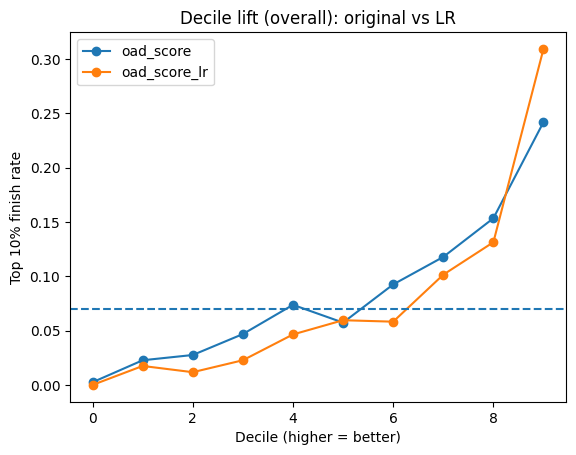

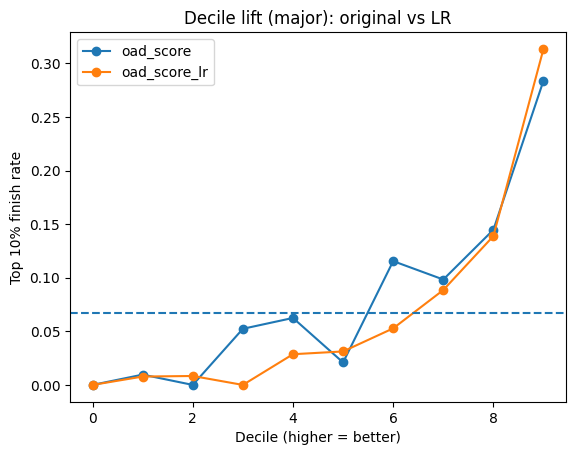

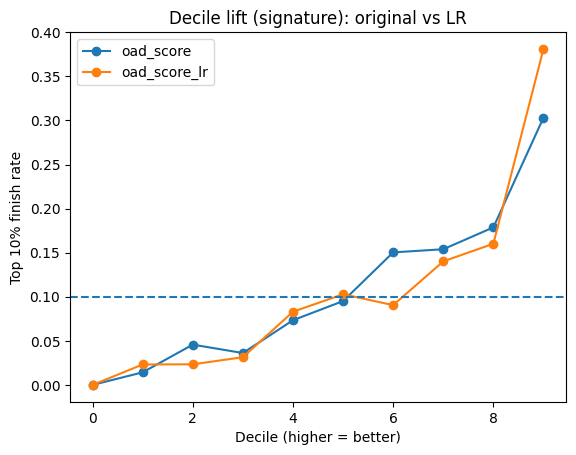

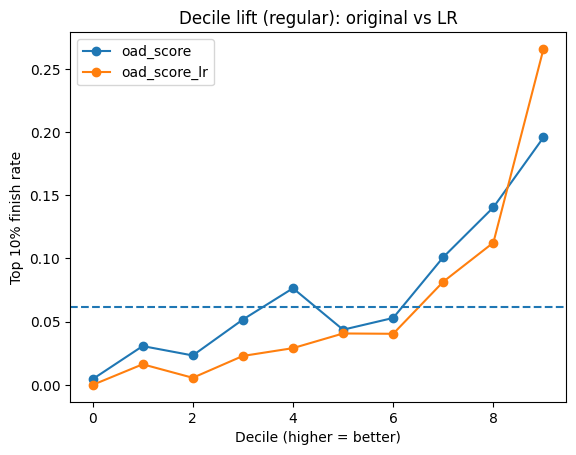

In [54]:
import matplotlib.pyplot as plt

def plot_decile_lift(df_in: pd.DataFrame, score_cols, title: str):
    plt.figure()
    for sc in score_cols:
        out = decile_lift(df_in, sc)
        plt.plot(out["decile"], out["avg_top10pct_rate"], marker="o", label=sc)
    plt.axhline(df_in["is_top10pct"].mean(), linestyle="--")
    plt.xlabel("Decile (higher = better)")
    plt.ylabel("Top 10% finish rate")
    plt.title(title)
    plt.legend()
    plt.show()

plot_decile_lift(df, ["oad_score", "oad_score_lr"], "Decile lift (overall): original vs LR")

for t in ["major","signature","regular"]:
    sub = df[df["tier"] == t].copy()
    if len(sub) == 0:
        continue
    plot_decile_lift(sub, ["oad_score", "oad_score_lr"], f"Decile lift ({t}): original vs LR")

# --------------------------

In [55]:
import numpy as np
import pandas as pd

# --- helpers ---
def within_event_pct_rank(df: pd.DataFrame, col: str) -> pd.Series:
    """
    Percentile rank within (year,event_id). Higher is better.
    Handles missing by leaving NaN.
    """
    s = pd.to_numeric(df[col], errors="coerce")

    def _pct(x: pd.Series) -> pd.Series:
        x = pd.to_numeric(x, errors="coerce")
        n = x.notna().sum()
        if n <= 1:
            return pd.Series([np.nan] * len(x), index=x.index)
        r = x.rank(method="average", ascending=True)  # low->high
        return (r - 1) / (n - 1)

    return df.groupby(["year", "event_id"])[s.name].transform(_pct)

def precision_at_k_by_event(df: pd.DataFrame, score_col: str, k: int = 1) -> pd.DataFrame:
    """
    For each event: rank players by score_col descending and compute whether any of top-k are top10pct.
    Returns one row per event with hit@k (0/1) and metadata.
    """
    tmp = df.copy()
    tmp[score_col] = pd.to_numeric(tmp[score_col], errors="coerce")

    # keep only rows with score present
    tmp = tmp[tmp[score_col].notna()].copy()

    rows = []
    for (y, eid), g in tmp.groupby(["year", "event_id"]):
        g2 = g.sort_values(score_col, ascending=False).head(k)
        hit = bool(g2["is_top10pct"].any())
        tier = str(g["tier"].iloc[0]) if "tier" in g.columns else ""
        rows.append({"year": int(y), "event_id": int(eid), "tier": tier, f"hit@{k}": int(hit), "n_scored": int(len(g))})
    return pd.DataFrame(rows)

def summarize_precision(df: pd.DataFrame, score_col: str, ks=(1,3)) -> pd.DataFrame:
    """
    Overall + by tier summary for hit@k event metrics.
    """
    out_rows = []
    for k in ks:
        ev = precision_at_k_by_event(df, score_col, k=k)
        if ev.empty:
            continue

        # overall
        out_rows.append({
            "scope": "overall",
            "score": score_col,
            "k": k,
            "events": int(len(ev)),
            "precision": float(ev[f"hit@{k}"].mean()),
        })

        # by tier
        for t in ["major", "signature", "regular"]:
            sub = ev[ev["tier"] == t]
            if len(sub) == 0:
                continue
            out_rows.append({
                "scope": t,
                "score": score_col,
                "k": k,
                "events": int(len(sub)),
                "precision": float(sub[f"hit@{k}"].mean()),
            })

    return pd.DataFrame(out_rows).sort_values(["k", "scope", "precision"], ascending=[True, True, False])

# --- build percentile-rank versions of the signals we care about ---
# (These are the columns we will evaluate / blend)
SIGNALS = ["oad_score", "sg_total_L12", "sg_total_L24", "ev_current_adj"]
SIGNALS = [c for c in SIGNALS if c in df.columns]

for c in SIGNALS:
    df[f"pct_{c}"] = within_event_pct_rank(df, c)

# sanity check
print("Signals used:", SIGNALS)
print(df[[f"pct_{c}" for c in SIGNALS]].describe().T[["mean","std","min","max"]].head())

# --- evaluate single-signal rankings (by percentile rank) ---
single_scores = [f"pct_{c}" for c in SIGNALS]
all_summaries = []
for sc in single_scores:
    summ = summarize_precision(df, sc, ks=(1,3))
    all_summaries.append(summ)

single_eval = pd.concat(all_summaries, ignore_index=True)
display(single_eval.sort_values(["k","scope","precision"], ascending=[True, True, False]))


Signals used: ['oad_score', 'sg_total_L12', 'sg_total_L24', 'ev_current_adj']
                     mean    std    min    max
pct_oad_score      0.5000 0.2914 0.0000 1.0000
pct_sg_total_L12   0.5000 0.2910 0.0000 1.0000
pct_sg_total_L24   0.5000 0.2910 0.0000 1.0000
pct_ev_current_adj 0.5000 0.2907 0.0000 1.0000


,scope,score,k,events,precision
0,major,pct_oad_score,1,8,0.8750
8,major,pct_sg_total_L12,1,8,0.8750
16,major,pct_sg_total_L24,1,8,0.8750
24,major,pct_ev_current_adj,1,8,0.8750
9,overall,pct_sg_total_L12,1,62,0.6452
17,overall,pct_sg_total_L24,1,62,0.5968
25,overall,pct_ev_current_adj,1,62,0.5806
1,overall,pct_oad_score,1,62,0.5645
10,regular,pct_sg_total_L12,1,34,0.5294
2,regular,pct_oad_score,1,34,0.4118
